<a href="https://colab.research.google.com/github/michaelchea30-prog/Final-Project---Data-Analytics-My-colab-Project-/blob/main/CYT180_finalproject_Michael_Chea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession  # add this import


spark = (
    SparkSession.builder
    .appName("DataCamp PySpark Tutorial")
    .config("spark.memory.offHeap.enabled", "true")
    .config("spark.memory.offHeap.size", "10g")
    .getOrCreate()
)


In [4]:
df = spark.read.csv("Online Retail.csv", header=True, escape='"', inferSchema=True)

In [5]:
df.show(5,0)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |2010-12-01 08:26:00|2.75     |17850     |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
+---------+-----

In [6]:
df.count()  # Answer: 2,500

541909

In [7]:
df.select('CustomerID').distinct().count() # Answer: 95

4373

In [9]:
import pyspark.sql.functions as F
from pyspark.sql.types import *

df.groupBy('Country').agg(F.countDistinct('CustomerID').alias('country_count')).show()

+------------------+-------------+
|           Country|country_count|
+------------------+-------------+
|            Sweden|            8|
|         Singapore|            1|
|           Germany|           95|
|               RSA|            1|
|            France|           87|
|            Greece|            4|
|European Community|            1|
|           Belgium|           25|
|           Finland|           12|
|             Malta|            2|
|       Unspecified|            4|
|             Italy|           15|
|              EIRE|            3|
|         Lithuania|            1|
|            Norway|           10|
|             Spain|           31|
|           Denmark|            9|
|         Hong Kong|            0|
|           Iceland|            1|
|            Israel|            4|
+------------------+-------------+
only showing top 20 rows


In [11]:
df.groupBy('Country').agg(F.countDistinct('CustomerID').alias('country_count')).orderBy(F.desc('country_count')).show()

+---------------+-------------+
|        Country|country_count|
+---------------+-------------+
| United Kingdom|         3950|
|        Germany|           95|
|         France|           87|
|          Spain|           31|
|        Belgium|           25|
|    Switzerland|           21|
|       Portugal|           19|
|          Italy|           15|
|        Finland|           12|
|        Austria|           11|
|         Norway|           10|
|        Denmark|            9|
|Channel Islands|            9|
|      Australia|            9|
|    Netherlands|            9|
|         Sweden|            8|
|         Cyprus|            8|
|          Japan|            8|
|         Poland|            6|
|         Greece|            4|
+---------------+-------------+
only showing top 20 rows


In [12]:
df = df.withColumn(
    "date",
    coalesce(
        to_timestamp(col("InvoiceDate"), "yy/MM/dd HH:mm"),
        to_timestamp(col("InvoiceDate"), "yyyy-MM-dd HH:mm:ss"),
        to_timestamp(col("InvoiceDate"))  # best-effort fallback
    )
)
df.select(max("date")).show()

+-------------------+
|          max(date)|
+-------------------+
|2011-12-09 12:50:00|
+-------------------+



In [13]:
df.select(min("date")).show()

+-------------------+
|          min(date)|
+-------------------+
|2010-12-01 08:26:00|
+-------------------+



In [14]:
df.show(5,0)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+-------------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |date               |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+-------------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |2010-12-01 08:26:00|2.75     |17850     |United Kingdom|2010-12-01 08:26:00|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|2010-12-01 08:26:00|

In [33]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# Drop rows with null CustomerID as RFM is customer-centric
cleaned_df = df.dropna(subset=['CustomerID'])

# Calculate Recency: days since last purchase
# Find the most recent date in the entire dataset
max_date_overall = cleaned_df.agg(F.max("date")).collect()[0][0]

recency_df = cleaned_df.groupBy('CustomerID').agg(
    F.max('date').alias('last_purchase_date')
).withColumn(
    'recency', F.datediff(F.lit(max_date_overall), F.col('last_purchase_date'))
).select('CustomerID', 'recency')

# Calculate Frequency: number of unique invoices per customer
frequency_df = cleaned_df.groupBy('CustomerID').agg(
    F.countDistinct('InvoiceNo').alias('frequency')
)

# Calculate Monetary: sum of (Quantity * UnitPrice) per customer
monetary_df = cleaned_df.withColumn(
    'TotalAmount', F.col('Quantity').cast('double') * F.col('UnitPrice').cast('double')
).groupBy('CustomerID').agg(
    F.sum('TotalAmount').alias('monetary_value')
)

# Join R, F, M DataFrames
rfm_df = recency_df.join(frequency_df, on='CustomerID', how='inner')
rfm_df = rfm_df.join(monetary_df, on='CustomerID', how='inner')

# Filter out rows where monetary_value is null or negative, or recency/frequency are invalid
rfm_df = rfm_df.filter(
    F.col('monetary_value').isNotNull() & (F.col('monetary_value') >= 0) &
    F.col('recency').isNotNull() & (F.col('recency') >= 0) &
    F.col('frequency').isNotNull() & (F.col('frequency') > 0)
)

# The 'finaldf' variable in the original problem statement corresponds to this rfm_df
finaldf = rfm_df

In [17]:
df2 = df2.join(df2.groupBy('CustomerID').agg(max('recency').alias('recency')),on='recency',how='leftsemi')

In [18]:
df2.show(5,0)

+--------+---------+---------+------------------------------+--------+-------------------+---------+----------+--------------+-------------------+-------------------+
|recency |InvoiceNo|StockCode|Description                   |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |date               |from_date          |
+--------+---------+---------+------------------------------+--------+-------------------+---------+----------+--------------+-------------------+-------------------+
|32234400|581498   |15056bl  |EDWARDIAN PARASOL BLACK       |2       |2011-12-09 10:26:00|12.46    |NULL      |United Kingdom|2011-12-09 10:26:00|2010-12-01 08:26:00|
|4153860 |C541433  |23166    |MEDIUM CERAMIC TOP STORAGE JAR|-74215  |2011-01-18 10:17:00|1.04     |12346     |United Kingdom|2011-01-18 10:17:00|2010-12-01 08:26:00|
|32081160|581180   |23497    |CLASSIC CHROME BICYCLE BELL   |12      |2011-12-07 15:52:00|1.45     |12347     |Iceland       |2011-12-07 15:52:00|2010-12-01 08:26:00

In [19]:
df2.printSchema()

root
 |-- recency: long (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = false)



In [20]:
df_freq = df2.groupBy('CustomerID').agg(count('InvoiceDate').alias('frequency'))

In [21]:
df_freq.show(5,0)

+----------+---------+
|CustomerID|frequency|
+----------+---------+
|12346     |1        |
|12347     |1        |
|12348     |1        |
|12349     |1        |
|12350     |1        |
+----------+---------+
only showing top 5 rows


In [22]:
df3 = df2.join(df_freq,on='CustomerID',how='inner')

In [23]:
df3.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- recency: long (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = false)
 |-- frequency: long (nullable = false)



In [24]:
m_val = df3.withColumn(
    "TotalAmount",
    col("Quantity").cast("double") * col("UnitPrice").cast("double")
)


In [25]:
m_val = m_val.groupBy('CustomerID').agg(sum('TotalAmount').alias('monetary_value'))

In [26]:
finaldf = m_val.join(df3,on='CustomerID',how='inner')

In [38]:
finaldf = finaldf.select(['recency','frequency','monetary_value','CustomerID']).distinct()

In [41]:
from pyspark.ml.clustering import KMeans
import pyspark.sql.functions as F

# Optimal k identified from the elbow plot
optimal_k = 4

# Initialize KMeans with the optimal k
km_final = KMeans(featuresCol="standardized", k=optimal_k, seed=42) # Added seed for reproducibility

# Fit the model to the cleaned data
model_final = km_final.fit(cleaned_data_scale_output)

# Transform the data to get cluster predictions
clustered_data = model_final.transform(cleaned_data_scale_output)

# Show the count of customers in each cluster
print(f"Customer distribution across {optimal_k} clusters:")
clustered_data.groupBy('prediction').count().orderBy('prediction').show()

# Show a sample of the clustered data
print("Sample of clustered data:")
clustered_data.select('CustomerID', 'recency', 'frequency', 'monetary_value', 'prediction').show(5)

Customer distribution across 4 clusters:
+----------+-----+
|prediction|count|
+----------+-----+
|         0| 3093|
|         1| 1059|
|         2|   11|
|         3|  166|
+----------+-----+

Sample of clustered data:
+----------+-------+---------+------------------+----------+
|CustomerID|recency|frequency|    monetary_value|prediction|
+----------+-------+---------+------------------+----------+
|     17389|      0|       43|          31300.08|         3|
|     13623|     30|        7|            672.44|         0|
|     14450|    180|        3|            483.25|         1|
|     15727|     16|        7| 5178.959999999999|         0|
|     13285|     23|        4|2709.1199999999994|         0|
+----------+-------+---------+------------------+----------+
only showing top 5 rows


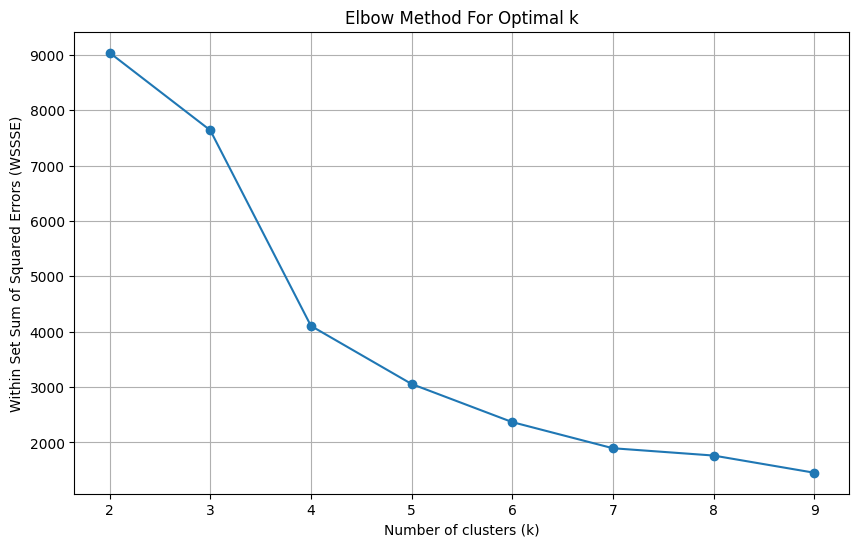

In [39]:
import matplotlib.pyplot as plt

# Ensure ks and cost are defined from previous cells
# If ks and cost are not defined, you might need to re-run the KMeans cell first.
# For example:
# ks = range(2, 10)
# cost = np.array([...]) # Populate with actual cost values if running this cell independently

plt.figure(figsize=(10, 6))
plt.plot(ks, cost, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within Set Sum of Squared Errors (WSSSE)')
plt.xticks(list(ks))
plt.grid(True)
plt.show()

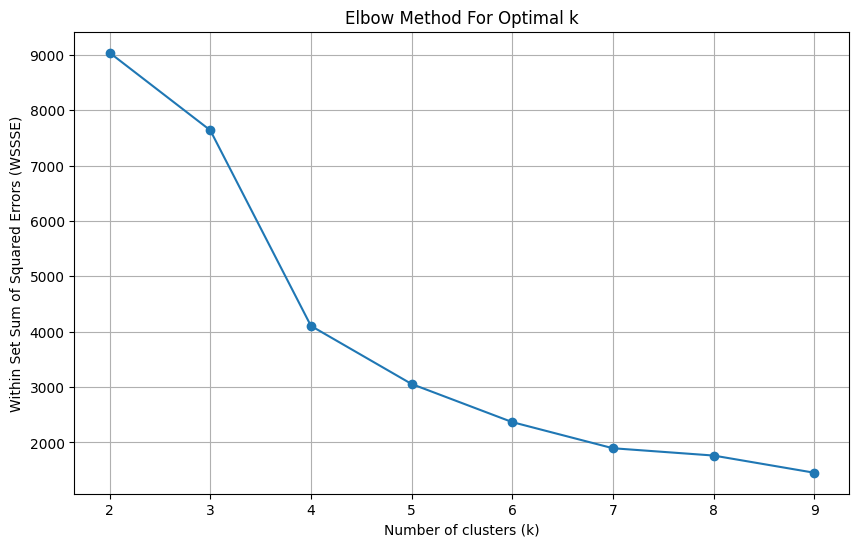

In [40]:
import matplotlib.pyplot as plt

# Ensure ks and cost are defined from previous cells
# If ks and cost are not defined, you might need to re-run the KMeans cell first.
# For example:
# ks = range(2, 10)
# cost = np.array([...]) # Populate with actual cost values if running this cell independently

plt.figure(figsize=(10, 6))
plt.plot(ks, cost, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within Set Sum of Squared Errors (WSSSE)')
plt.xticks(list(ks))
plt.grid(True)
plt.show()

In [35]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

assemble = VectorAssembler(
    inputCols=["recency", "frequency", "monetary_value"],
    outputCol="features"
)
assembled_data = assemble.transform(finaldf)


scale = StandardScaler(inputCol="features", outputCol="standardized")
data_scale = scale.fit(assembled_data)
data_scale_output = data_scale.transform(assembled_data)

In [36]:
data_scale_output.select('standardized').show(2,truncate=False)

+-------------------------------------------------------------+
|standardized                                                 |
+-------------------------------------------------------------+
|[0.5043426043627514,0.31990473205463904,0.07252563770488421] |
|[0.5951242731480466,0.31990473205463904,0.018366669936285236]|
+-------------------------------------------------------------+
only showing top 2 rows


In [37]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import numpy as np
import pyspark.sql.functions as F # Ensure F is imported

cost = np.zeros(10)

evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="standardized",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)


ks = range(2, 10)
cost = np.zeros(len(ks))

# Filter out rows with any null values.
# A NullPointerException during KMeans fit often indicates NaN or null values in the feature column
# or other columns used in internal Spark operations. Dropping all rows with any null value
# should ensure data integrity for the clustering process.
cleaned_data_scale_output = data_scale_output.na.drop()

for idx, k in enumerate(ks):
    km = KMeans(featuresCol="standardized", k=k)
    # Fit KMeans on the cleaned data
    model = km.fit(cleaned_data_scale_output)
    output = model.transform(cleaned_data_scale_output)
    cost[idx] = model.summary.trainingCost   # WSSSE

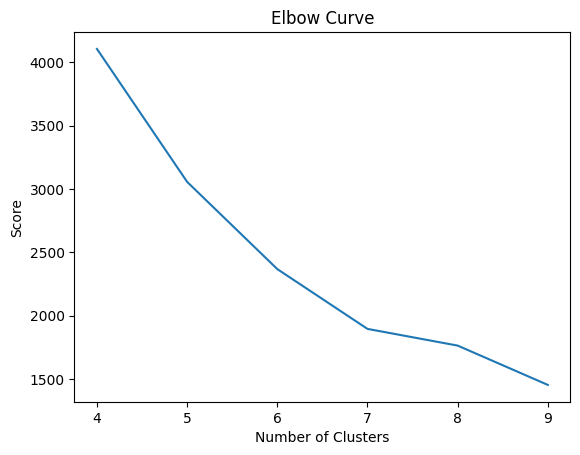

In [43]:
import pandas as pd
import pylab as pl
# df_cost is created from cost[2:], which has 6 elements (cost for k=4 to k=9)
df_cost = pd.DataFrame(cost[2:])
df_cost.columns = ["cost"]
# new_col should also have 6 elements, corresponding to k=4 to k=9
new_col = range(4,10)
df_cost.insert(0, 'cluster', new_col)
pl.plot(df_cost.cluster, df_cost.cost)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [44]:
KMeans_algo=KMeans(featuresCol='standardized', k=4)
KMeans_fit=KMeans_algo.fit(data_scale_output)

In [45]:
preds=KMeans_fit.transform(data_scale_output)

preds.show(5,0)

+----------+-------+---------+------------------+-----------------------------+------------------------------------------------------------+----------+
|CustomerID|recency|frequency|monetary_value    |features                     |standardized                                                |prediction|
+----------+-------+---------+------------------+-----------------------------+------------------------------------------------------------+----------+
|17389     |0      |43       |31300.08          |[0.0,43.0,31300.08]          |[0.0,4.585301159449826,3.7908225409780596]                  |3         |
|13623     |30     |7        |672.44            |[30.0,7.0,672.44]            |[0.30260556261765087,0.7464443747941578,0.0814407090798262] |0         |
|14450     |180    |3        |483.25            |[180.0,3.0,483.25]           |[1.815633375705905,0.31990473205463904,0.0585274859657754]  |2         |
|15727     |16     |7        |5178.959999999999 |[16.0,7.0,5178.959999999999] |[0.161389

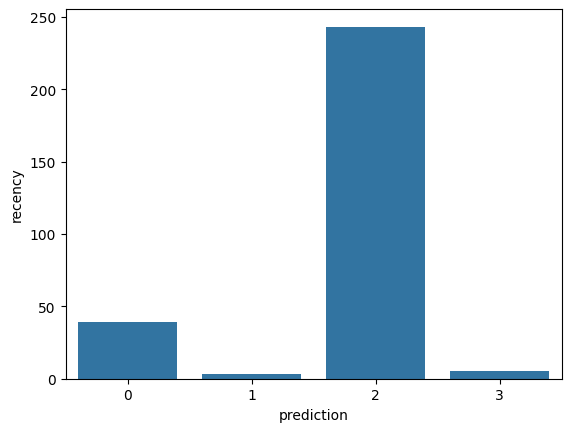

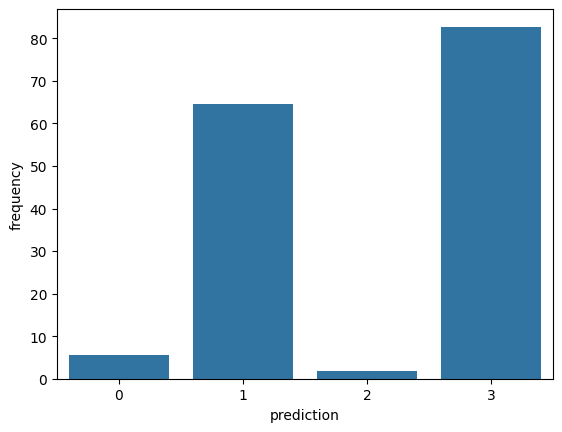

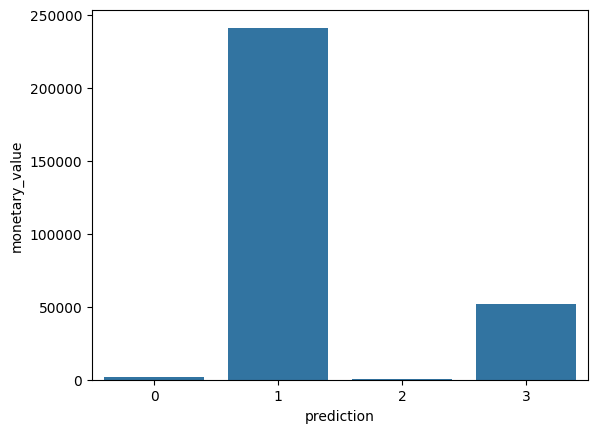

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = preds.select('recency','frequency','monetary_value','prediction')
df_viz = df_viz.toPandas()
avg_df = df_viz.groupby(['prediction'], as_index=False).mean()

list1 = ['recency','frequency','monetary_value']

for i in list1:
    sns.barplot(x='prediction',y=str(i),data=avg_df)
    plt.show()